# Figure Remake — Study 1 (Mirrored) & Study 2A/2B (Grouped Bars)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict

mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "lines.markersize": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("Setup complete.")

Setup complete.


## Helper Functions

In [ ]:
def get_dist7(probs_dict):
    d = np.array([float(probs_dict.get(str(i), 0) or 0) for i in range(1, 8)])
    return d / d.sum() if d.sum() > 0 else d

def add_significance_bracket(ax, x1, x2, y, text, lw=0.8, fontsize=8):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05
    ax.plot([x1, x1, x2, x2], [y, y+0.5*h, y+0.5*h, y], color='black', linewidth=lw, clip_on=False)
    ax.text((x1+x2)/2, y+0.5*h+0.5, text, ha='center', va='bottom', fontsize=fontsize)

MODEL_COLORS = {
    "GPT-4o": "#10A37F",        # OpenAI green (ChatGPT brand)
    "DeepSeek": "#2563EB",      # deep blue (DeepSeek branding direction)
    "DeepSeek-V3.2": "#2563EB",

    "Phi-4": "#F97316",         # Microsoft orange (Phi / Azure tone)
    
    "Qwen": "#8B5CF6",          # Alibaba purple (cleaner than current)
    "Qwen-2.5": "#8B5CF6",

    "OLMo": "#6B7280",          # neutral gray (AI2 minimal style)
    "OLMo-2": "#6B7280",
    "Olmo-3.5": "#6B7280",
}

C_PRIOR = "#4A5A8A"
C_CUE = "#C0392B"

print("Helpers loaded.")

---
# Study 1: Mirrored Distance Plot

## Load Study 1 Data

In [ ]:
# ══════════════════════════════════════════
# UPDATE THESE PATHS
# ══════════════════════════════════════════
STUDY1_MODELS = {
    "GPT-4o": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/baseline_outputs_explicit_format.jsonl",
        "full": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/study1_results.jsonl",
    },
    "DeepSeek": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/outputs/deepseek_study1_baseline_results.jsonl",
        "full": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/outputs/deepseek_study1_full_results.jsonl",
    },
    "Phi-4": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_baseline_results.jsonl",
        "full": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_full_results.jsonl",
    },
    "Qwen": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/qwen_study1_baseline_results.jsonl",
        "full": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/qwen_study1_full_results.jsonl",
    },
}

def load_study1_model(paths):
    """Load baseline + full results, compute oppose-trial ΔP by distance."""
    # Load baseline
    bl = {}
    with open(paths["baseline"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            probs = resp.get("probs", {})
            if qid and probs:
                dist = get_dist7(probs)
                bl[qid] = {"dist": dist, "mode": int(np.argmax(dist)) + 1}

    # Load full results, filter oppose trials
    records = []
    with open(paths["full"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            probs = resp.get("probs", {})
            if not probs: continue

            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            if qid not in bl: continue

            cue_dir = str(md.get("cue_direction", md.get("condition", ""))).lower()
            if "oppose" not in cue_dir: continue

            cue_target = md.get("cue_target")
            cue_distance = md.get("cue_distance")
            if cue_target is None or cue_target == "none": continue
            cue_target = int(cue_target)
            if cue_distance is not None and cue_distance != "none":
                cue_distance = int(cue_distance)
            else:
                cue_distance = abs(cue_target - bl[qid]["mode"])

            post_dist = get_dist7(probs)
            base_dist = bl[qid]["dist"]
            mode = bl[qid]["mode"]

            records.append({
                "cue_distance": cue_distance,
                "delta_p_prior": post_dist[mode - 1] - base_dist[mode - 1],
                "delta_p_cue": post_dist[cue_target - 1] - base_dist[cue_target - 1],
            })

    # Aggregate by distance
    dist_groups = defaultdict(list)
    for r in records:
        dist_groups[r["cue_distance"]].append(r)

    distances = np.array(sorted(dist_groups.keys()))
    mean_dp_prior, ci_dp_prior = [], []
    mean_dp_cue, ci_dp_cue = [], []

    for d in distances:
        subset = dist_groups[d]
        n = len(subset)
        dp_prior = np.array([r["delta_p_prior"] for r in subset])
        dp_cue = np.array([r["delta_p_cue"] for r in subset])
        mean_dp_prior.append(dp_prior.mean())
        ci_dp_prior.append(1.96 * dp_prior.std(ddof=1) / np.sqrt(n) if n > 1 else 0)
        mean_dp_cue.append(dp_cue.mean())
        ci_dp_cue.append(1.96 * dp_cue.std(ddof=1) / np.sqrt(n) if n > 1 else 0)

    return {
        "distances": distances,
        "mean_dp_prior": np.array(mean_dp_prior),
        "ci_dp_prior": np.array(ci_dp_prior),
        "mean_dp_cue": np.array(mean_dp_cue),
        "ci_dp_cue": np.array(ci_dp_cue),
        "n_trials": len(records),
    }

# Load all models
model_data = {}
for name, paths in STUDY1_MODELS.items():
    try:
        model_data[name] = load_study1_model(paths)
        print(f"{name}: {model_data[name]['n_trials']} oppose trials")
    except Exception as e:
        print(f"{name}: FAILED — {e}")

## Plot Study 1: Mirrored Distance (2×2)

In [ ]:
def plot_mirrored(ax, data, model_label, show_legend=False):
    d = data["distances"]
    # ΔP(prior) — negative, goes downward
    ax.plot(d, data["mean_dp_prior"], "o-", color=C_PRIOR, markersize=3,
            linewidth=1.2, zorder=3, label=r"$\Delta P(\text{prior})$")
    ax.fill_between(d, data["mean_dp_prior"] - data["ci_dp_prior"],
                     data["mean_dp_prior"] + data["ci_dp_prior"],
                     color=C_PRIOR, alpha=0.15, linewidth=0, zorder=2)

    # ΔP(cue target) — positive, goes upward
    ax.plot(d, data["mean_dp_cue"], "s-", color=C_CUE, markersize=3,
            linewidth=1.2, zorder=3, label=r"$\Delta P(\text{cue target})$")
    ax.fill_between(d, data["mean_dp_cue"] - data["ci_dp_cue"],
                     data["mean_dp_cue"] + data["ci_dp_cue"],
                     color=C_CUE, alpha=0.15, linewidth=0, zorder=2)

    ax.axhline(0, color="black", linewidth=0.6, linestyle="--", zorder=1)
    ax.set_xticks(d)
    ax.text(0.03, 0.97, model_label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")
    if show_legend:
        ax.legend(loc="lower left", frameon=True, framealpha=0.4,
                  edgecolor="#DDD", fontsize=6.5)


models_to_plot = list(model_data.keys())
n = len(models_to_plot)


if n <= 4:
    fig, axes = plt.subplots(2, 2, figsize=(5.5, 4.0), sharex=True)
    axes = axes.flatten()
else:
    fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.0), sharex=True)
    axes = axes.flatten()

for i, name in enumerate(models_to_plot):
    plot_mirrored(axes[i], model_data[name], name,
                  show_legend=(i == 0))
    if i % (3 if n > 4 else 2) == 0:
        axes[i].set_ylabel(r"$\Delta P$")
    if i >= (3 if n > 4 else 2):
        axes[i].set_xlabel(r"$|i_{\text{target}} - i_{\text{mode}}|$")

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(w_pad=0.8, h_pad=0.8)
plt.savefig("fig_study1_mirrored_all.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_study1_mirrored_all.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("Study 1 figure saved.")

---
# Study 2A & 2B: Grouped Bar Charts

## Load Study 2 Additional Data

In [ ]:
# ══════════════════════════════════════════
# UPDATE THESE PATHS
# ══════════════════════════════════════════
STUDY2_MODELS = {
    "GPT-4o": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/baseline_outputs_explicit_format.jsonl",
        "additional": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/outputs/gpt4o_study2_additional_results.jsonl",
    },
    "DeepSeek": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/baseline_outputs_explicit_format.jsonl",
        "additional": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/outputs/deepseek_study2_additional_results.jsonl",
    },
    "Phi-4": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/baseline_outputs_explicit_format.jsonl",
        "additional": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/phi4_study2_additional_results.jsonl",
    },
    "Qwen": {
        "baseline": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/baseline_outputs_explicit_format.jsonl",
        "additional": "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/qwen_study2_additional_results.jsonl",
    },
}

def load_study2_rates(paths):
    """Load Study 2 additional results and compute commitment rates."""
    bl = {}
    with open(paths["baseline"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            probs = resp.get("probs", {})
            if qid and probs:
                dist = get_dist7(probs)
                bl[qid] = {"dist": dist, "mode": int(np.argmax(dist)) + 1}

    exp2a = defaultdict(lambda: {"commit": 0, "total": 0})
    exp2b = defaultdict(lambda: {"commit": 0, "total": 0})

    with open(paths["additional"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            probs = resp.get("probs", {})
            if not probs: continue
            qid = md.get("qid")
            if qid not in bl: continue

            post_dist = get_dist7(probs)
            irr = md["irrational_choice"]
            mode = md["mode_choice"]
            committed = post_dist[irr - 1] > post_dist[mode - 1]

            exp = md.get("experiment")
            stage = md.get("stage")
            if stage != "commit": continue

            if exp == "2A":
                framing = md.get("framing")
                exp2a[framing]["total"] += 1
                if committed: exp2a[framing]["commit"] += 1
            elif exp == "2B":
                attr = md.get("attribution")
                exp2b[attr]["total"] += 1
                if committed: exp2b[attr]["commit"] += 1

    rates_2a = {}
    for f in ["memory", "instruction", "suggestion"]:
        t = exp2a[f]["total"]
        rates_2a[f] = (exp2a[f]["commit"] / t * 100) if t > 0 else 0

    rates_2b = {}
    for a in ["self", "user", "other_ai"]:
        t = exp2b[a]["total"]
        rates_2b[a] = (exp2b[a]["commit"] / t * 100) if t > 0 else 0

    return rates_2a, rates_2b

# Load all
exp2a_data = {}
exp2b_data = {}
for name, paths in STUDY2_MODELS.items():
    try:
        r2a, r2b = load_study2_rates(paths)
        exp2a_data[name] = r2a
        exp2b_data[name] = r2b
        print(f"{name} 2A: mem={r2a['memory']:.1f}%, inst={r2a['instruction']:.1f}%, sug={r2a['suggestion']:.1f}%")
        print(f"{name} 2B: self={r2b['self']:.1f}%, user={r2b['user']:.1f}%, other={r2b['other_ai']:.1f}%")
    except Exception as e:
        print(f"{name}: FAILED — {e}")

## Plot Experiment 2A: Grouped Bars (Commitment Rate by Framing)

In [ ]:
models = list(exp2a_data.keys())
n_models = len(models)
framings = ["Memory", "Instruction", "Suggestion"]
framing_keys = ["memory", "instruction", "suggestion"]

fig, ax = plt.subplots(figsize=(4.5, 2.5))

x_group = np.arange(len(framings))
total_width = 0.75
bar_width = total_width / n_models

for j, model_name in enumerate(models):
    offset = (j - (n_models - 1) / 2) * bar_width
    rates = [exp2a_data[model_name][k] for k in framing_keys]
    ax.bar(x_group + offset, rates, bar_width * 0.88,
           color=MODEL_COLORS.get(model_name, "#999"),
           edgecolor="white", linewidth=0.5, alpha=0.75,
           label=model_name)
    # for i, v in enumerate(rates):
    #     ax.text(x_group[i] + offset, v + 1.5, f"{v:.0f}",
    #             ha='center', va='bottom', fontsize=5, fontweight='bold')

ax.set_xticks(x_group)
ax.set_xticklabels(framings, fontsize=8)
ax.set_ylabel(r"Commitment rate ($\%$)", fontsize=8)
ax.set_ylim(0, 118)
ax.legend(fontsize=6, loc="upper right", ncol=2, frameon=True,
          framealpha=0.9, edgecolor="#DDD", columnspacing=0.8,
          handlelength=1.2, handletextpad=0.4, bbox_to_anchor=(1, 0.9))

# Significance bracket: Memory vs Suggestion
add_significance_bracket(ax, x_group[0], x_group[2], 120, "***")
# Memory vs Instruction
add_significance_bracket(ax, x_group[0], x_group[1], 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2a_grouped.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2a_grouped.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("Exp 2A figure saved.")

## Plot Experiment 2B: Grouped Bars (Commitment Rate by Attribution)

In [ ]:
models = list(exp2b_data.keys())
n_models = len(models)
attributions = ["Self", "User", "Other AI"]
attr_keys = ["self", "user", "other_ai"]

fig, ax = plt.subplots(figsize=(4.5, 2.5))

x_group = np.arange(len(attributions))
total_width = 0.75
bar_width = total_width / n_models

for j, model_name in enumerate(models):
    offset = (j - (n_models - 1) / 2) * bar_width
    rates = [exp2b_data[model_name][k] for k in attr_keys]
    ax.bar(x_group + offset, rates, bar_width * 0.88,
           color=MODEL_COLORS.get(model_name, "#999"),
           edgecolor="white", linewidth=0.5, alpha=0.85,
           label=model_name)

ax.set_xticks(x_group)
ax.set_xticklabels(attributions, fontsize=8)
ax.set_ylabel("Commitment rate (%)", fontsize=8)
ax.set_ylim(0., 140)
ax.legend(fontsize=6, loc="upper right", ncol=2, frameon=True,
          framealpha=0.9, edgecolor="#DDD", columnspacing=0.8,
          handlelength=1.2, handletextpad=0.4)

# Significance bracket: Self vs Other AI
add_significance_bracket(ax, x_group[0], x_group[2], 120, "***")
# Self vs User
add_significance_bracket(ax, x_group[0], x_group[1], 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2b_grouped.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2b_grouped.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("Exp 2B figure saved.")

In [ ]:


# ═══════════════════════════════════════════════════════════════
# Modified loader — returns trial-level binary arrays
# ═══════════════════════════════════════════════════════════════
def load_study2_trials(paths):
    """Load Study 2 additional results, return per-trial committed (0/1)."""
    bl = {}
    with open(paths["baseline"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            probs = resp.get("probs", {})
            if qid and probs:
                dist = get_dist7(probs)
                bl[qid] = {"dist": dist, "mode": int(np.argmax(dist)) + 1}

    exp2a_trials = defaultdict(list)  # framing -> [0/1, 0/1, ...]
    exp2b_trials = defaultdict(list)  # attribution -> [0/1, 0/1, ...]

    with open(paths["additional"]) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            md = obj.get("metadata", {})
            probs = resp.get("probs", {})
            if not probs: continue
            qid = md.get("qid")
            if qid not in bl: continue

            post_dist = get_dist7(probs)
            irr = md["irrational_choice"]
            mode = md["mode_choice"]
            committed = int(post_dist[irr - 1] > post_dist[mode - 1])

            exp = md.get("experiment")
            stage = md.get("stage")
            if stage != "commit": continue

            if exp == "2A":
                framing = md.get("framing")
                exp2a_trials[framing].append(committed)
            elif exp == "2B":
                attr = md.get("attribution")
                exp2b_trials[attr].append(committed)

    # Convert to numpy arrays
    for k in exp2a_trials:
        exp2a_trials[k] = np.array(exp2a_trials[k])
    for k in exp2b_trials:
        exp2b_trials[k] = np.array(exp2b_trials[k])

    return dict(exp2a_trials), dict(exp2b_trials)

# Load all trial-level data
exp2a_trials = {}
exp2b_trials = {}
for name, paths in STUDY2_MODELS.items():
    try:
        t2a, t2b = load_study2_trials(paths)
        exp2a_trials[name] = t2a
        exp2b_trials[name] = t2b
        for fk in ["memory", "instruction", "suggestion"]:
            arr = t2a.get(fk, np.array([]))
            print(f"  {name} 2A {fk}: n={len(arr)}, rate={arr.mean()*100:.1f}%")
    except Exception as e:
        print(f"{name}: FAILED — {e}")


# ═══════════════════════════════════════════════════════════════
# Exp 2A — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches

models = list(exp2a_trials.keys())
n_models = len(models)
framings = ["Memory", "Instruction", "Suggestion"]
framing_keys = ["memory", "instruction", "suggestion"]

fig, ax = plt.subplots(figsize=(5.5, 3.2))

total_width = 0.72
box_width = total_width / n_models
jitter_width = box_width * 0.35
n_boot = 200
np.random.seed(42)

for i, (framing_label, fk) in enumerate(zip(framings, framing_keys)):
    for j, model in enumerate(models):
        offset = (j - (n_models - 1) / 2) * box_width
        pos = i + offset

        raw = exp2a_trials[model].get(fk, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        jx = pos + np.random.uniform(-jitter_width, jitter_width, size=len(boot_rates))
        ax.scatter(jx, boot_rates, s=6, alpha=0.35,
                   color=MODEL_COLORS[model], edgecolors="none", zorder=2)

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(pos, mean_r, "D", color=MODEL_COLORS[model],
                markersize=4, markeredgecolor="white", markeredgewidth=0.6, zorder=4)
        ax.plot([pos, pos], [mean_r - ci, mean_r + ci],
                color=MODEL_COLORS[model], linewidth=1.5, zorder=3, solid_capstyle="round")

handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.7,
                          edgecolor="white", linewidth=0.5, label=m)
           for m in models]
ax.legend(handles=handles, fontsize=6, loc="upper right", ncol=2,
          frameon=True, framealpha=0.9, edgecolor="#DDD",
          columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

ax.set_xticks(range(len(framings)))
ax.set_xticklabels(framings)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 125)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2a_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2a_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()


# ═══════════════════════════════════════════════════════════════
# Exp 2B — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models_2b = list(exp2b_trials.keys())
n_models_2b = len(models_2b)
attributions = ["Self", "User", "Other AI"]
attr_keys = ["self", "user", "other_ai"]

fig, ax = plt.subplots(figsize=(5.5, 3.2))

total_width_2b = 0.72
box_width_2b = total_width_2b / n_models_2b
jitter_width_2b = box_width_2b * 0.35

for i, (attr_label, ak) in enumerate(zip(attributions, attr_keys)):
    for j, model in enumerate(models_2b):
        offset = (j - (n_models_2b - 1) / 2) * box_width_2b
        pos = i + offset

        raw = exp2b_trials[model].get(ak, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        jx = pos + np.random.uniform(-jitter_width_2b, jitter_width_2b, size=len(boot_rates))
        ax.scatter(jx, boot_rates, s=6, alpha=0.35,
                   color=MODEL_COLORS[model], edgecolors="none", zorder=2)

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(pos, mean_r, "D", color=MODEL_COLORS[model],
                markersize=4, markeredgecolor="white", markeredgewidth=0.6, zorder=4)
        ax.plot([pos, pos], [mean_r - ci, mean_r + ci],
                color=MODEL_COLORS[model], linewidth=1.5, zorder=3, solid_capstyle="round")

handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.7,
                          edgecolor="white", linewidth=0.5, label=m)
           for m in models_2b]
ax.legend(handles=handles, fontsize=6, loc="upper right", ncol=2,
          frameon=True, framealpha=0.9, edgecolor="#DDD",
          columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

ax.set_xticks(range(len(attributions)))
ax.set_xticklabels(attributions)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 125)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2b_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2b_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Exp 2A — Boxplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches

models = list(exp2a_trials.keys())
n_models = len(models)
framings = ["Memory", "Instruction", "Suggestion"]
framing_keys = ["memory", "instruction", "suggestion"]

fig, ax = plt.subplots(figsize=(5.5, 3.2))

total_width = 0.72
box_width = total_width / n_models
n_boot = 200
np.random.seed(42)

for i, (framing_label, fk) in enumerate(zip(framings, framing_keys)):
    for j, model in enumerate(models):
        offset = (j - (n_models - 1) / 2) * box_width
        pos = i + offset

        raw = exp2a_trials[model].get(fk, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = [
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ]

        bp = ax.boxplot(
            [boot_rates],
            positions=[pos],
            widths=box_width * 0.78,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="white", linewidth=1.2),
            whiskerprops=dict(color=MODEL_COLORS[model], linewidth=0.8),
            capprops=dict(color=MODEL_COLORS[model], linewidth=0.8),
        )
        bp["boxes"][0].set_facecolor(MODEL_COLORS[model])
        bp["boxes"][0].set_alpha(0.7)
        bp["boxes"][0].set_edgecolor("white")
        bp["boxes"][0].set_linewidth(0.5)

handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.7,
                          edgecolor="white", linewidth=0.5, label=m)
           for m in models]
ax.legend(handles=handles, fontsize=6, loc="upper right", ncol=2,
          frameon=True, framealpha=0.9, edgecolor="#DDD",
          columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

ax.set_xticks(range(len(framings)))
ax.set_xticklabels(framings)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 125)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2a_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2a_boxplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()


# ═══════════════════════════════════════════════════════════════
# Exp 2B — Boxplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models_2b = list(exp2b_trials.keys())
n_models_2b = len(models_2b)
attributions = ["Self", "User", "Other AI"]
attr_keys = ["self", "user", "other_ai"]

fig, ax = plt.subplots(figsize=(5.5, 3.2))

total_width_2b = 0.72
box_width_2b = total_width_2b / n_models_2b

for i, (attr_label, ak) in enumerate(zip(attributions, attr_keys)):
    for j, model in enumerate(models_2b):
        offset = (j - (n_models_2b - 1) / 2) * box_width_2b
        pos = i + offset

        raw = exp2b_trials[model].get(ak, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = [
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ]

        bp = ax.boxplot(
            [boot_rates],
            positions=[pos],
            widths=box_width_2b * 0.78,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="white", linewidth=1.2),
            whiskerprops=dict(color=MODEL_COLORS[model], linewidth=0.8),
            capprops=dict(color=MODEL_COLORS[model], linewidth=0.8),
        )
        bp["boxes"][0].set_facecolor(MODEL_COLORS[model])
        bp["boxes"][0].set_alpha(0.7)
        bp["boxes"][0].set_edgecolor("white")
        bp["boxes"][0].set_linewidth(0.5)

handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.7,
                          edgecolor="white", linewidth=0.5, label=m)
           for m in models_2b]
ax.legend(handles=handles, fontsize=6, loc="upper right", ncol=2,
          frameon=True, framealpha=0.9, edgecolor="#DDD",
          columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

ax.set_xticks(range(len(attributions)))
ax.set_xticklabels(attributions)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 125)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2b_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2b_boxplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "lines.markersize": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ═══════════════════════════════════════════════════════════════
# Modified loader — returns trial-level binary arrays
# ═══════════════════════════════════════════════════════════════
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

def load_study2_trials(paths):
    """Load Study 2 additional results, return per-trial committed (0/1)."""
    bl = {}
    with open(paths["baseline"]) as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200:
                continue
            md = obj.get("metadata", {})
            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            probs = resp.get("probs", {})
            if qid and probs:
                dist = get_dist7(probs)
                bl[qid] = {"dist": dist, "mode": int(np.argmax(dist)) + 1}

    exp2a_trials = defaultdict(list)  # framing -> [0/1, 0/1, ...]
    exp2b_trials = defaultdict(list)  # attribution -> [0/1, 0/1, ...]

    with open(paths["additional"]) as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200:
                continue
            md = obj.get("metadata", {})
            probs = resp.get("probs", {})
            if not probs:
                continue
            qid = md.get("qid")
            if qid not in bl:
                continue

            post_dist = get_dist7(probs)
            irr = md["irrational_choice"]
            mode = md["mode_choice"]
            committed = int(post_dist[irr - 1] > post_dist[mode - 1])

            exp = md.get("experiment")
            stage = md.get("stage")
            if stage != "commit":
                continue

            if exp == "2A":
                framing = md.get("framing")
                exp2a_trials[framing].append(committed)
            elif exp == "2B":
                attr = md.get("attribution")
                exp2b_trials[attr].append(committed)

    for k in exp2a_trials:
        exp2a_trials[k] = np.array(exp2a_trials[k])
    for k in exp2b_trials:
        exp2b_trials[k] = np.array(exp2b_trials[k])

    return dict(exp2a_trials), dict(exp2b_trials)


# ═══════════════════════════════════════════════════════════════
# Load all trial-level data
# ═══════════════════════════════════════════════════════════════
exp2a_trials = {}
exp2b_trials = {}

for name, paths in STUDY2_MODELS.items():
    try:
        t2a, t2b = load_study2_trials(paths)
        exp2a_trials[name] = t2a
        exp2b_trials[name] = t2b
        for fk in ["memory", "instruction", "suggestion"]:
            arr = t2a.get(fk, np.array([]))
            if len(arr) > 0:
                print(f"  {name} 2A {fk}: n={len(arr)}, rate={arr.mean()*100:.1f}%")
            else:
                print(f"  {name} 2A {fk}: n=0")
    except Exception as e:
        print(f"{name}: FAILED — {e}")


# ═══════════════════════════════════════════════════════════════
# Shared settings for clearer swarm spacing
# ═══════════════════════════════════════════════════════════════
n_boot = 200
np.random.seed(42)

POINT_SIZE = 12
POINT_ALPHA = 0.07
JITTER_SCALE = 0.2          # narrower base spread than before
GAUSSIAN_MULTIPLIER = 0.40   # tighter concentration near center


# ═══════════════════════════════════════════════════════════════
# Exp 2A — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models = list(exp2a_trials.keys())
n_models = len(models)
framings = ["Memory", "Instruction", "Suggestion"]
framing_keys = ["memory", "instruction", "suggestion"]

fig, ax = plt.subplots(figsize=(4, 3.2))

total_width = 0.6
box_width = total_width / n_models
jitter_width = box_width * JITTER_SCALE

for i, (framing_label, fk) in enumerate(zip(framings, framing_keys)):
    for j, model in enumerate(models):
        offset = (j - (n_models - 1) / 2) * box_width
        pos = i + offset

        raw = exp2a_trials[model].get(fk, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        # Gaussian horizontal jitter for cleaner, more natural spacing
        jx = pos + np.random.normal(0, jitter_width * GAUSSIAN_MULTIPLIER, size=len(boot_rates))

        ax.scatter(
            jx,
            boot_rates,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=MODEL_COLORS[model],
            edgecolors="none",
            zorder=2
        )

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(
            pos, mean_r, "D",
            color=MODEL_COLORS[model],
            markersize=4,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4
        )
        ax.plot(
            [pos, pos], [mean_r - ci, mean_r + ci],
            color=MODEL_COLORS[model],
            linewidth=1.5,
            zorder=3,
            solid_capstyle="round"
        )

handles = [
    mpatches.Patch(
        facecolor=MODEL_COLORS[m],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
        label=m
    )
    for m in models
]
ax.legend(
    handles=handles,
    fontsize=8,
    loc="upper right",
    ncol=2,
    frameon=False,
    framealpha=0.5,
    edgecolor="#DDD",
    columnspacing=0.8,
    handlelength=1.2,
    handletextpad=0.4,
    bbox_to_anchor=(1.1, 0.975)
)

ax.set_xticks(range(len(framings)))
ax.set_xticklabels(framings)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 105)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2a_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2a_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()


# ═══════════════════════════════════════════════════════════════
# Exp 2B — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models_2b = list(exp2b_trials.keys())
n_models_2b = len(models_2b)
attributions = ["Self", "User", "Other AI"]
attr_keys = ["self", "user", "other_ai"]

fig, ax = plt.subplots(figsize=(4., 3.2))

total_width_2b = 0.72
box_width_2b = total_width_2b / n_models_2b
jitter_width_2b = box_width_2b * JITTER_SCALE

for i, (attr_label, ak) in enumerate(zip(attributions, attr_keys)):
    for j, model in enumerate(models_2b):
        offset = (j - (n_models_2b - 1) / 2) * box_width_2b
        pos = i + offset

        raw = exp2b_trials[model].get(ak, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        # Gaussian horizontal jitter for cleaner, more natural spacing
        jx = pos + np.random.normal(0, jitter_width_2b * GAUSSIAN_MULTIPLIER, size=len(boot_rates))

        ax.scatter(
            jx,
            boot_rates,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=MODEL_COLORS[model],
            edgecolors="none",
            zorder=2
        )

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(
            pos, mean_r, "D",
            color=MODEL_COLORS[model],
            markersize=4,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4
        )
        ax.plot(
            [pos, pos], [mean_r - ci, mean_r + ci],
            color=MODEL_COLORS[model],
            linewidth=1.5,
            zorder=3,
            solid_capstyle="round"
        )

handles = [
    mpatches.Patch(
        facecolor=MODEL_COLORS[m],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
        label=m
    )
    for m in models_2b
]
# ax.legend(
#     handles=handles,
#     fontsize=8,
#     loc="upper right",
#     ncol=2,
#     frameon=True,
#     framealpha=0.5,
#     edgecolor="#DDD",
#     columnspacing=0.8,
#     handlelength=1.2,
#     handletextpad=0.4,
#     bbox_to_anchor=(1, 0.97)
# )

ax.set_xticks(range(len(attributions)))
ax.set_xticklabels(attributions)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 105)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2b_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2b_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()

  GPT-4o 2A memory: n=145, rate=89.7%
  GPT-4o 2A instruction: n=145, rate=75.9%
  GPT-4o 2A suggestion: n=145, rate=29.0%
  DeepSeek 2A memory: n=424, rate=79.7%
  DeepSeek 2A instruction: n=424, rate=54.5%
  DeepSeek 2A suggestion: n=424, rate=36.3%
  Phi-4 2A memory: n=205, rate=17.6%
  Phi-4 2A instruction: n=205, rate=96.6%
  Phi-4 2A suggestion: n=205, rate=30.2%
  Qwen 2A memory: n=294, rate=100.0%
  Qwen 2A instruction: n=294, rate=89.5%
  Qwen 2A suggestion: n=294, rate=46.6%


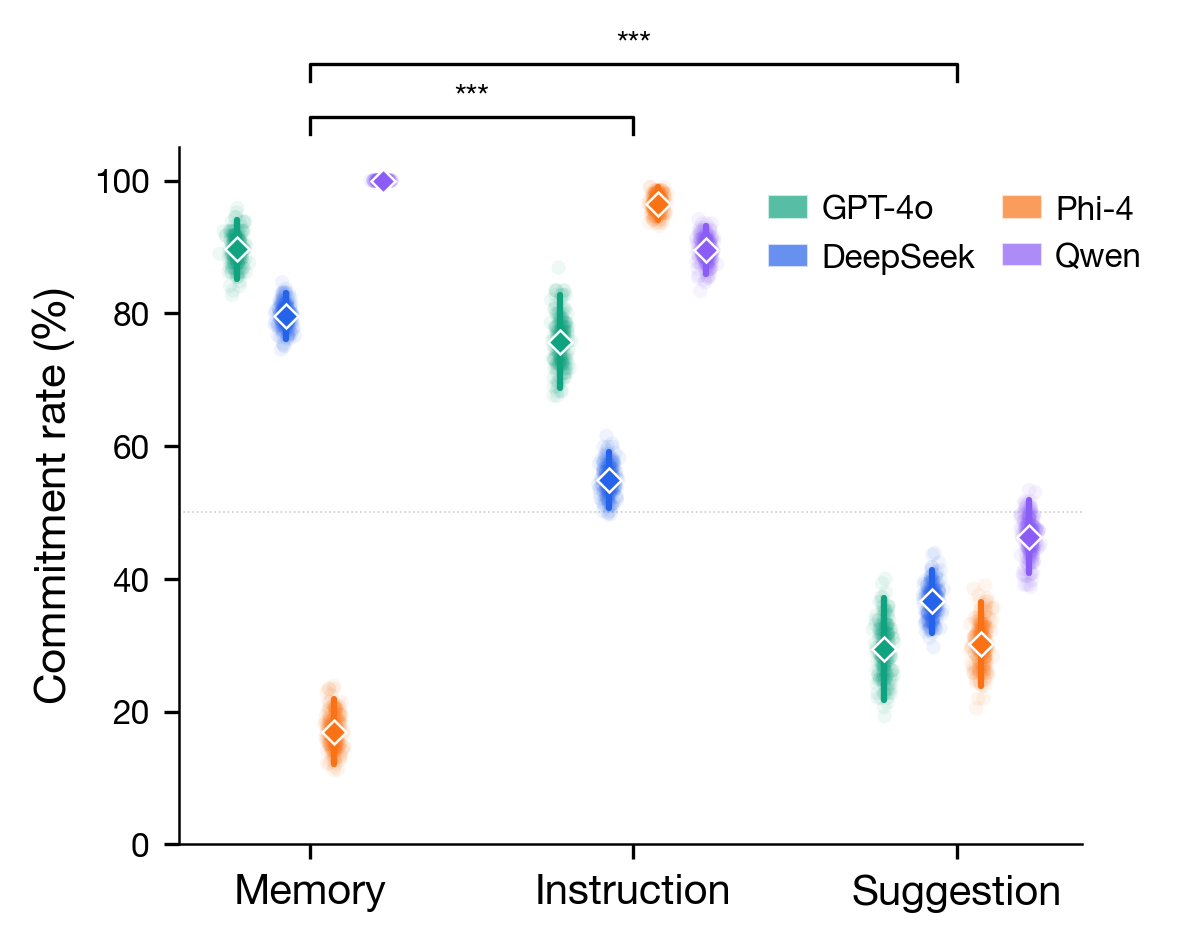

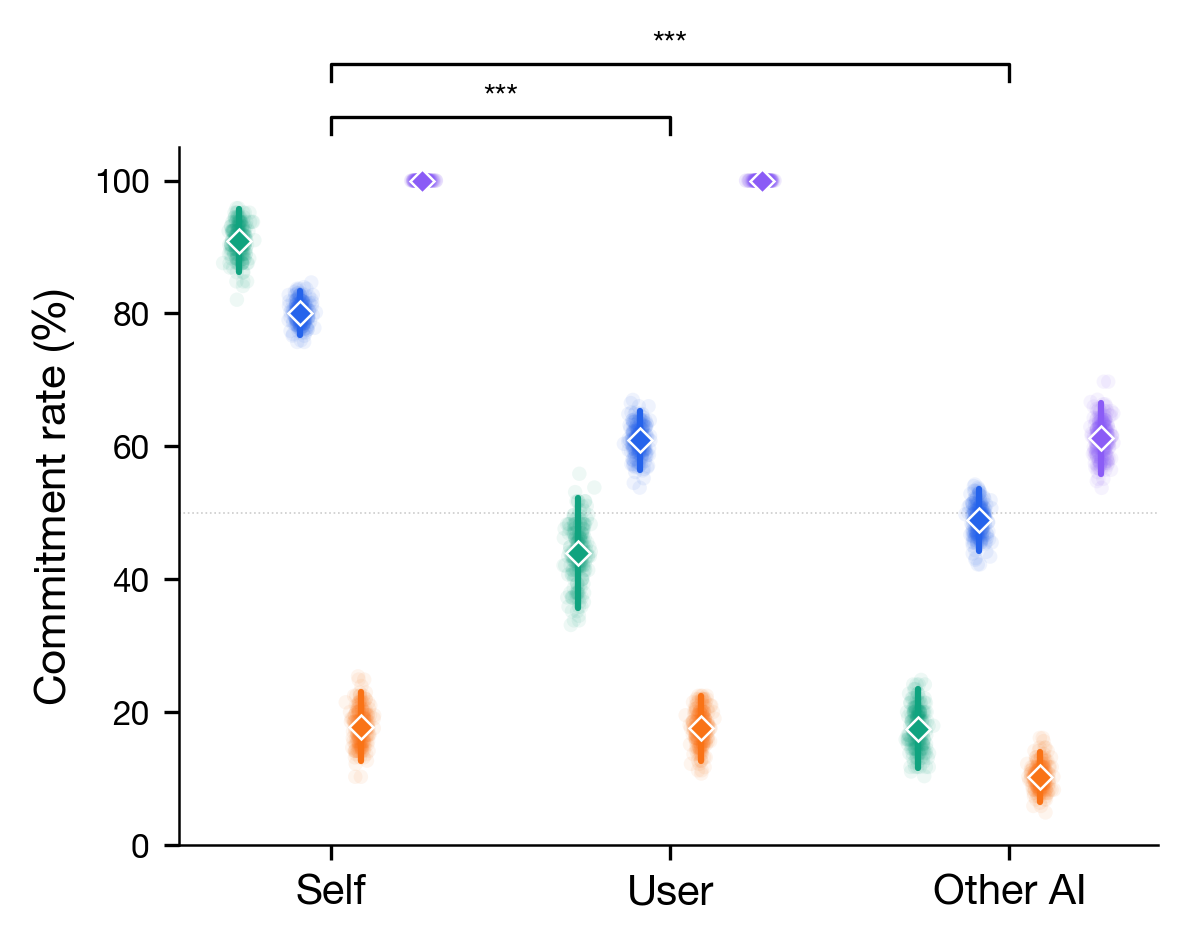

In [77]:
mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "lines.markersize": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ═══════════════════════════════════════════════════════════════
# Modified loader — returns trial-level binary arrays
# ═══════════════════════════════════════════════════════════════
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

def load_study2_trials(paths):
    """Load Study 2 additional results, return per-trial committed (0/1)."""
    bl = {}
    with open(paths["baseline"]) as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200:
                continue
            md = obj.get("metadata", {})
            qid = md.get("qid") or obj.get("custom_id", "").split("|")[0]
            probs = resp.get("probs", {})
            if qid and probs:
                dist = get_dist7(probs)
                bl[qid] = {"dist": dist, "mode": int(np.argmax(dist)) + 1}

    exp2a_trials = defaultdict(list)  # framing -> [0/1, 0/1, ...]
    exp2b_trials = defaultdict(list)  # attribution -> [0/1, 0/1, ...]

    with open(paths["additional"]) as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200:
                continue
            md = obj.get("metadata", {})
            probs = resp.get("probs", {})
            if not probs:
                continue
            qid = md.get("qid")
            if qid not in bl:
                continue

            post_dist = get_dist7(probs)
            irr = md["irrational_choice"]
            mode = md["mode_choice"]
            committed = int(post_dist[irr - 1] > post_dist[mode - 1])

            exp = md.get("experiment")
            stage = md.get("stage")
            if stage != "commit":
                continue

            if exp == "2A":
                framing = md.get("framing")
                exp2a_trials[framing].append(committed)
            elif exp == "2B":
                attr = md.get("attribution")
                exp2b_trials[attr].append(committed)

    for k in exp2a_trials:
        exp2a_trials[k] = np.array(exp2a_trials[k])
    for k in exp2b_trials:
        exp2b_trials[k] = np.array(exp2b_trials[k])

    return dict(exp2a_trials), dict(exp2b_trials)


# ═══════════════════════════════════════════════════════════════
# Load all trial-level data
# ═══════════════════════════════════════════════════════════════
exp2a_trials = {}
exp2b_trials = {}

for name, paths in STUDY2_MODELS.items():
    try:
        t2a, t2b = load_study2_trials(paths)
        exp2a_trials[name] = t2a
        exp2b_trials[name] = t2b
        for fk in ["memory", "instruction", "suggestion"]:
            arr = t2a.get(fk, np.array([]))
            if len(arr) > 0:
                print(f"  {name} 2A {fk}: n={len(arr)}, rate={arr.mean()*100:.1f}%")
            else:
                print(f"  {name} 2A {fk}: n=0")
    except Exception as e:
        print(f"{name}: FAILED — {e}")


# ═══════════════════════════════════════════════════════════════
# Shared settings for clearer swarm spacing
# ═══════════════════════════════════════════════════════════════
n_boot = 200
np.random.seed(42)

POINT_SIZE = 12
POINT_ALPHA = 0.07
JITTER_SCALE = 0.2          # narrower base spread than before
GAUSSIAN_MULTIPLIER = 0.40   # tighter concentration near center


# ═══════════════════════════════════════════════════════════════
# Exp 2A — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models = list(exp2a_trials.keys())
n_models = len(models)
framings = ["Memory", "Instruction", "Suggestion"]
framing_keys = ["memory", "instruction", "suggestion"]

fig, ax = plt.subplots(figsize=(4, 3.2))

total_width = 0.6
box_width = total_width / n_models
jitter_width = box_width * JITTER_SCALE

for i, (framing_label, fk) in enumerate(zip(framings, framing_keys)):
    for j, model in enumerate(models):
        offset = (j - (n_models - 1) / 2) * box_width
        pos = i + offset

        raw = exp2a_trials[model].get(fk, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        # Gaussian horizontal jitter for cleaner, more natural spacing
        jx = pos + np.random.normal(0, jitter_width * GAUSSIAN_MULTIPLIER, size=len(boot_rates))

        ax.scatter(
            jx,
            boot_rates,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=MODEL_COLORS[model],
            edgecolors="none",
            zorder=2
        )

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(
            pos, mean_r, "D",
            color=MODEL_COLORS[model],
            markersize=4,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4
        )
        ax.plot(
            [pos, pos], [mean_r - ci, mean_r + ci],
            color=MODEL_COLORS[model],
            linewidth=1.5,
            zorder=3,
            solid_capstyle="round"
        )

handles = [
    mpatches.Patch(
        facecolor=MODEL_COLORS[m],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
        label=m
    )
    for m in models
]
ax.legend(
    handles=handles,
    fontsize=8,
    loc="upper right",
    ncol=2,
    frameon=False,
    framealpha=0.5,
    edgecolor="#DDD",
    columnspacing=0.8,
    handlelength=1.2,
    handletextpad=0.4,
    bbox_to_anchor=(1.1, 0.975)
)

ax.set_xticks(range(len(framings)))
ax.set_xticklabels(framings)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 105)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2a_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2a_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()


# ═══════════════════════════════════════════════════════════════
# Exp 2B — Swarmplot (bootstrapped commitment rates)
# ═══════════════════════════════════════════════════════════════
models_2b = list(exp2b_trials.keys())
n_models_2b = len(models_2b)
attributions = ["Self", "User", "Other AI"]
attr_keys = ["self", "user", "other_ai"]

fig, ax = plt.subplots(figsize=(4., 3.2))

total_width_2b = 0.72
box_width_2b = total_width_2b / n_models_2b
jitter_width_2b = box_width_2b * JITTER_SCALE

for i, (attr_label, ak) in enumerate(zip(attributions, attr_keys)):
    for j, model in enumerate(models_2b):
        offset = (j - (n_models_2b - 1) / 2) * box_width_2b
        pos = i + offset

        raw = exp2b_trials[model].get(ak, np.array([]))
        if len(raw) == 0:
            continue

        boot_rates = np.array([
            np.mean(np.random.choice(raw, size=len(raw), replace=True)) * 100
            for _ in range(n_boot)
        ])

        # Gaussian horizontal jitter for cleaner, more natural spacing
        jx = pos + np.random.normal(0, jitter_width_2b * GAUSSIAN_MULTIPLIER, size=len(boot_rates))

        ax.scatter(
            jx,
            boot_rates,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=MODEL_COLORS[model],
            edgecolors="none",
            zorder=2
        )

        mean_r = boot_rates.mean()
        ci = 1.96 * boot_rates.std()
        ax.plot(
            pos, mean_r, "D",
            color=MODEL_COLORS[model],
            markersize=4,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4
        )
        ax.plot(
            [pos, pos], [mean_r - ci, mean_r + ci],
            color=MODEL_COLORS[model],
            linewidth=1.5,
            zorder=3,
            solid_capstyle="round"
        )

handles = [
    mpatches.Patch(
        facecolor=MODEL_COLORS[m],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
        label=m
    )
    for m in models_2b
]
# ax.legend(
#     handles=handles,
#     fontsize=8,
#     loc="upper right",
#     ncol=2,
#     frameon=True,
#     framealpha=0.5,
#     edgecolor="#DDD",
#     columnspacing=0.8,
#     handlelength=1.2,
#     handletextpad=0.4,
#     bbox_to_anchor=(1, 0.97)
# )

ax.set_xticks(range(len(attributions)))
ax.set_xticklabels(attributions)
ax.set_ylabel(r"Commitment rate ($\%$)")
ax.set_ylim(0, 105)
ax.axhline(50, color="#CCC", linewidth=0.4, linestyle=":", zorder=0)

add_significance_bracket(ax, 0, 2, 115, "***")
add_significance_bracket(ax, 0, 1, 107, "***")

plt.tight_layout()
plt.savefig("fig_exp2b_swarmplot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_exp2b_swarmplot.pdf", bbox_inches="tight", facecolor="white")
plt.show()